In [ ]:
!pip install pandas numpy matplotlib seaborn -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Combined Data.csv')
df = df[['statement', 'status']].copy()
df.columns = ['text', 'label']

print('Shape:', df.shape)
print(df['label'].value_counts())
df.head()

Shape: (53044, 2)
label
Normal                  16351
Depression              15404
Suicidal                10652
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [2]:
# Remove null values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates(subset='text')

# Reset index
df = df.reset_index(drop=True)

print('After cleaning:', df.shape)
print('Null values:', df.isnull().sum())

After cleaning: (51068, 2)
Null values: text     0
label    0
dtype: int64


In [3]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_text)
print('Done!')
print(df[['text', 'text_clean']].head(3))

Done!
                                                text  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   

                                          text_clean  
0                                         oh my gosh  
1  trouble sleeping confused mind restless heart ...  
2  all wrong back off dear forward doubt stay in ...  


In [4]:
label2id = {label: i for i, label in enumerate(df['label'].unique())}
id2label = {i: label for label, i in label2id.items()}

df['label_id'] = df['label'].map(label2id)

print('Label mapping:', label2id)
print(df[['label', 'label_id']].head(10))

Label mapping: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
     label  label_id
0  Anxiety         0
1  Anxiety         0
2  Anxiety         0
3  Anxiety         0
4  Anxiety         0
5  Anxiety         0
6  Anxiety         0
7  Anxiety         0
8  Anxiety         0
9  Anxiety         0


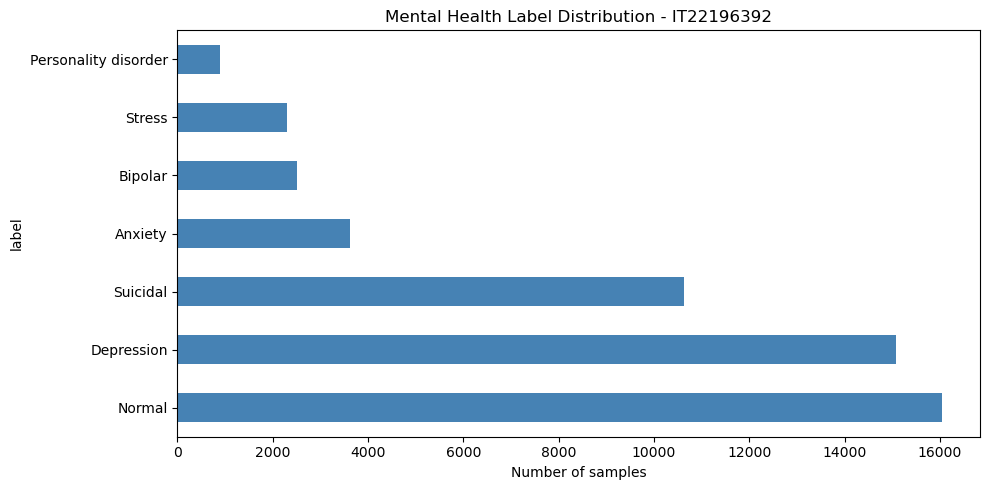

label
Normal                  16039
Depression              15085
Suicidal                10638
Anxiety                  3617
Bipolar                  2501
Stress                   2293
Personality disorder      895
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(10, 5))
label_counts = df['label'].value_counts()
label_counts.plot(kind='barh', color='steelblue')
plt.title('Mental Health Label Distribution - IT22196392')
plt.xlabel('Number of samples')
plt.tight_layout()
plt.savefig('../results/figures/label_distribution.png', dpi=150)
plt.show()
print(label_counts)

In [6]:
df.to_csv('../data/cleaned_data.csv', index=False)
print('Saved! Shape:', df.shape)
print('Columns:', df.columns.tolist())

Saved! Shape: (51068, 4)
Columns: ['text', 'label', 'text_clean', 'label_id']
